In [19]:
import jax
jax.config.update("jax_enable_x64", True)

# An Introduction to Modeling Dynamical Systems Driven by Partial Differential Equations

Consider a time-dependent function $u(t,x)$ representing the state of some underlying physical system. In many cases, this function is characterized as the solution of a partial differential equation

$$
\frac{\partial u}{\partial t} = Lu + f(x, u, \partial_{x} u, \partial_{xx}u, \dots),
$$

subject to some boundary conditions, where $L$ is a linear differential operator and $f$ is a (generally nonlinear) function of $u$ and possibly its spatial derivatives.

## Discretization of PDEs

Solving a time-dependent PDE numerically requires a choice of spatial discretization: the solution $u(t,x)$ is expressed either in a finite-dimensional basis, global (Fourier, Chebyshev polynomials) or local (Lagrange polynomials, B-splines), or via a spatial discretization scheme such as finite differences or finite volumes. Under any of these choices, the PDE reduces to an ODE over the discretized state $\mathbf{u}(t) \in \mathbb{R}^n$:

$$
\frac{d\mathbf{u}}{dt} = A\mathbf{u} + f(\mathbf{u}),
$$

where $A$ is the matrix representation of the discretized operator $L$, and the boundary conditions are typically absorbed into the definition of $\mathbf{u}$ and $A$. This reduction turns the problem of inferring unknowns in a PDE into inferring unknowns in an ODE, exactly the class of problem dynestyx is built to handle, letting us place priors over initial conditions and unknown parameters and run standard probabilistic-programming inference directly on the resulting finite-dimensional dynamical system.

Numerically, the ODE can be solved using either an explicit or an implicit time-marching scheme, such as the forward and backward Euler schemes:
$$
\begin{aligned}
\mathbf{u}^{n+1} &= \mathbf{u}^n + \Delta t\big( A \mathbf{u}^n + f(\mathbf{u}^n) \big) \quad &&\text{Explicit: the RHS depends only on } \mathbf{u}^n\\[4pt]
\mathbf{u}^{n+1} &= \mathbf{u}^n + \Delta t\big( A \mathbf{u}^{n+1} + f(\mathbf{u}^{n+1}) \big) \quad &&\text{Implicit: the RHS depends only on } \mathbf{u}^{n+1}\\[4pt]
\end{aligned}
$$
A single step of an explicit scheme is the cheapest to compute, but for stiff systems (such as diffusion equations) may require an unrealistically small $\Delta t$ to remain numerically stable. Implicit schemes remain stable at much larger step sizes, at the cost of a full nonlinear solve at each step. Implicit-explicit (IMEX) methods combine the advantages of both by splitting the right-hand side into an implicit part (often the linear operator $A$) and an explicit part (often the nonlinearity $f$); these are not yet supported in dynestyx.

# A First Model: Linear Heat Equation

As a first example, we consider the linear heat equation with zero Dirichlet boundary conditions:

$$
\begin{aligned}
&\frac{\partial u}{\partial t} = \nu\Delta u \quad && (x,t) \in (0, T) \times (0,1)\\
& u(t, 0) = u(t, 1) = 0 \quad && x \in \{0,1\}\\
& u(0, x)= u_0 \quad && x \in [0,1]
\end{aligned}
$$

where $\Delta := \frac{\partial^2 }{\partial x^2}$ is the one-dimensional Laplacian. Discretizing space on a uniform grid $x_i$ and writing $\mathbf{u}^t_i = u(t, x_i)$, the discrete Laplacian is

$$
\Delta \mathbf{u}^t_i = \frac{\mathbf{u}^t_{i+1} -2\mathbf{u}^t_{i} + \mathbf{u}^t_{i-1}}{h^2}.
$$

In matrix form this is $\Delta \mathbf{u} = A\mathbf{u}$, where, on the interior nodes (the boundary values are held fixed at zero by the Dirichlet condition), $A$ is the tridiagonal matrix

$$
A = \frac{1}{h^2}
\begin{pmatrix}
-2 & 1 & & & \\
1 & -2 & 1 & & \\
 & \ddots & \ddots & \ddots & \\
 & & 1 & -2 & 1 \\
 & & & 1 & -2
\end{pmatrix}.
$$

The dynamics are then given by the linear model

$$
\frac{d\mathbf{u}}{dt}(t) = \nu A \mathbf{u}(t).
$$

The initial condition is a smooth Gaussian bump multiplied by a sine factor to ensure compatibility with the zero Dirichlet boundary condition:

$$
u_0(x) = \exp\Big(-\frac{(x -\mu)^2}{0.5}\Big)\sin(\pi x).
$$

The bump's center $\mu$ is the unknown parameter we aim to recover.

In [20]:
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import ContinuousTimeStateEvolution, DynamicalModel, LinearGaussianObservation
from dynestyx.inference.configs.filter import ContinuousTimeKFConfig
from dynestyx import Simulator, Filter
import diffrax as dfx

import jax.random as jr
from numpyro.infer import Predictive

from dynestyx import ODESimulator
from numpyro.distributions.transforms import LowerCholeskyAffine
from numpyro.distributions import constraints


In [21]:
# Discretization parametes (if the simulation is too slow, try reducing these)
spatial_discretization = 2**5 # spatial discretization for the simulation
dt = 1e-1 # time step for the simulation (ony an initial guess, the ODE solver will adaptively choose the time step)
obs_time = jnp.linspace(0, 1, 2**5)

In [22]:
# Building the discrete laplacian operator for the heat equation (interior nodes only)
nu = 1e-2  # diffusion coefficient
n = spatial_discretization
x_full = jnp.linspace(0, 1, n, endpoint=True)
h = x_full[1] - x_full[0]
x = x_full[1:-1]  # interior nodes; boundary values are fixed at 0 by the Dirichlet BC

n_interior = n - 2
A = (jnp.diag(-2.0 * jnp.ones(n_interior))
     + jnp.diag(jnp.ones(n_interior - 1), 1)
     + jnp.diag(jnp.ones(n_interior - 1), -1)) / h**2 * nu

# Initial condition parameter
mu_true = 0.5

In [23]:
# define the initial condition a function of mu and x.
initial_condition = lambda mu : jnp.exp(- (x - mu)**2/(2*0.1**2)) * jnp.sin(jnp.pi*x)
ic_noise = 1e-2 # the noise on the initial condition
obs_noise = 1e-2 # the noise on the observations


def heat_equation_model(mu=None, obs_times=None, obs_values=None, predict_times=None):
    mu = numpyro.sample("mu", dist.Uniform(0, 1), obs=mu)

    # Create the dynamical model with sampled mu
    # Reparameterize the initial condition (this will be relevant when running MCMC directly on the model)
    standard_x0 = dist.MultivariateNormal(
        loc=jnp.zeros(n_interior),
        scale_tril=jnp.eye(n_interior),
    )

    initial_distribution = dist.TransformedDistribution(
        standard_x0,
        LowerCholeskyAffine(
            loc=initial_condition(mu),
            scale_tril=ic_noise * jnp.eye(n_interior),
        ),
    )

    dynamics = DynamicalModel(
        initial_condition=initial_distribution,
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: A @ x,
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(n_interior), R=obs_noise**2 * jnp.eye(n_interior)
        ),
    )

    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, predict_times=predict_times)

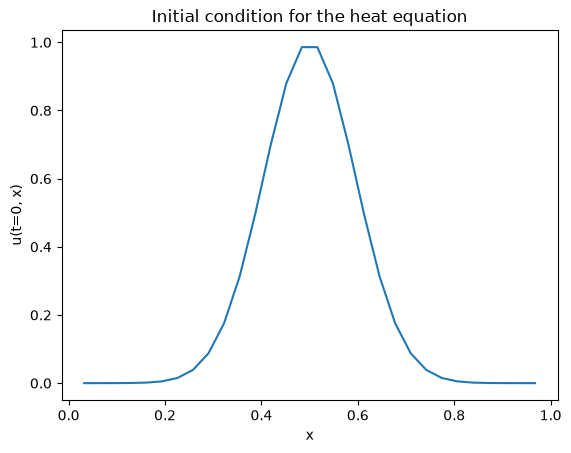

In [24]:
plt.plot(x, initial_condition(mu_true))
plt.title("Initial condition for the heat equation")
plt.xlabel("x")
plt.ylabel("u(t=0, x)")
plt.show()

## Generating the Solution 

In [ ]:
prng_key = jr.PRNGKey(0)
key, subkey = jr.split(prng_key)
predictive_model = Predictive(heat_equation_model, num_samples=1)

    
with ODESimulator(
    dsx.ODESimulatorConfig(
        solver=dfx.ImplicitEuler(), # note the implicit solver is used here
        stepsize_controller=dfx.PIDController(rtol=1e-3, atol=1e-3),
        dt0=dt,
        max_steps=10**6,
    )
):
    pde_solution = predictive_model(predict_times=obs_time, obs_values=None, mu=mu_true, rng_key=subkey)

## Visualizing the Solution

We plot the sampled realization as a space-time heatmap. Since we solved for the interior nodes only, we pad the state back out with the (fixed, zero) Dirichlet boundary values before plotting.

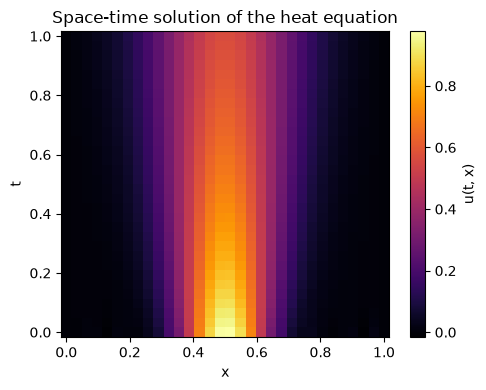

In [26]:
u = pde_solution["f_states"][0, 0]  # (n_times, n_interior)
u_full = jnp.pad(u, ((0, 0), (1, 1)))  # add back the fixed zero boundary values

fig, ax = plt.subplots(figsize=(5, 4))
mesh = ax.pcolormesh(x_full, obs_time, u_full, shading="auto", cmap="inferno")
fig.colorbar(mesh, ax=ax, label="u(t, x)")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("Space-time solution of the heat equation")
plt.tight_layout()
plt.show()

# Inferring the Initial Condition Using NUTS Through the Solver

We can now run NUTS directly under `LatentPathBuilder`: NUTS backpropagates straight through the PDE solve ("unrolling"), the same
pattern used in the ODE tutorial.

**A note about reparametrization and the funnel issue in MCMC.**

In the above, we have defined
$$
u_0 \mid \mu \sim \mathcal N\big(m(\mu),\ \sigma^2 I\big), \qquad \sigma = \texttt{ic\_noise} = 10^{-2},
$$
with $m(\mu) = $ `initial_condition(mu)`. Because $\sigma$ is small, this creates a funnel and MCMC stalls when trying to explore $(\mu, u_0)$. Instead we reparametrize as
$$
z \sim \mathcal N(0, I), \qquad u_0 = m(\mu) + \sigma z.
$$
Under the prior, $\mu$ and $z$ are independent: the $\sigma$-scale coupling is now a fixed deterministic map rather than part of the sampled density, so NUTS explores $(\mu, z)$ under a far better-conditioned posterior.

Importantly, this issue is not present when running the Kalman Filter below, as we automatically marginalize over $u_0$, preventing this issue.

In [27]:
from numpyro.infer import MCMC, NUTS

# Manual non-centered reparameterization.
def reparam_heat_equation_model(obs_times=None, obs_values=None):
    mu = numpyro.sample("mu", dist.Uniform(0, 1))
    z = numpyro.sample("z", dist.Normal(0, 1).expand([n_interior]).to_event(1))
    u_0 = initial_condition(mu) + ic_noise * z

    dynamics = DynamicalModel(
        initial_condition=dist.ImproperUniform(constraints.real, (), (n_interior,)),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: A @ x,
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(n_interior), R=obs_noise**2 * jnp.eye(n_interior)
        ),
    )

    return dsx.sample(
        "f", dynamics, obs_times=obs_times, obs_values=obs_values,
        state_path_params=u_0[None, :],
    )

with dsx.LatentPathBuilder(
    ode_simulator_config=dsx.ODESimulatorConfig(
        solver=dfx.ImplicitEuler(), # note the use of the implicit solver here, unconditionally stable for stiff problems like the heat equation
        stepsize_controller=dfx.PIDController(rtol=1e-3, atol=1e-3),
        dt0=dt,
        max_steps=10**6,
    )
):
    nuts_kernel = NUTS(reparam_heat_equation_model, step_size=1e-4)
    mcmc = MCMC(nuts_kernel, num_warmup=75, num_samples=75)
    mcmc.run(
        jr.PRNGKey(1),
        obs_times=pde_solution["f_times"][0, 0],
        obs_values=pde_solution["f_observations"][0, 0],
    )
posterior = mcmc.get_samples()
print("Posterior mu mean:", float(jnp.mean(posterior["mu"])))
print("Posterior mu std:", float(jnp.std(posterior["mu"])))
print("True mu:", mu_true)

sample: 100%|██████████| 150/150 [00:49<00:00,  3.04it/s, 1023 steps of size 7.08e-04. acc. prob=0.93]

Posterior mu mean: 0.5010291848209313
Posterior mu std: 0.000380041485904417
True mu: 0.5


# Inference With the Continuous-Time Kalman Filter

Since the discretized `heat_equation` is a linear-Gaussian state-space model, we can a continuous-time Kalman to get the exact densities and use this within MCMC, as an alternative to running MCMC through the simulation. 

**A note about solvers used for filtering.** We must first define a new model that uses the LTI module present within dynestyx. This model is mathematically identical to the previous, but under the hood will call an SDE solver instead. This limitation is due to the use of the ``ContinuousTimeKalmanFilter`` which assumes that system is stochastic and will run its own default internal SDE solver (as of version 0.1.0 this cannot yet be customized). Other filters, such as the ``EnsembleKalmanFilter`` do not suffer from these limitations and for an example of this in practice, please consult the tutorial on the reaction diffusion PDE.

In [28]:
def heat_equation(obs_times=None, obs_values=None, predict_times=None):
    mu = numpyro.sample("mu", dist.Uniform(0.0, 1.0))
    dynamics =dsx.LTI_continuous(
    A=A,                                  
    L=jnp.eye(x.shape[0])*0.0,                     # no diffusion (note that under the hood, this will use an SDE solver)
    H=jnp.eye(x.shape[0]),                         # observe the full state 
    R=obs_noise**2 * jnp.eye(x.shape[0]),          # small observation noise 
    initial_mean=initial_condition(mu),            # initial condition mean
    initial_cov=ic_noise**2*jnp.eye(x.shape[0]),   # initial condition covariance
)
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

We now use the continuous time Kalman filter to obtain the marginal densities $p(\theta | y_{1:T})$ and run MCMC. In this case, the Kalman filter provides exact marginals.

In [29]:
# note how no reparameterization is used here becauea the KF marginalizes out the initial state
def filtered_parameter_model():
    with Filter(
        filter_config=ContinuousTimeKFConfig( # the continuous-time Kalman filter.
            record_filtered_states_mean=True,
        )
    ):
        return heat_equation(obs_times=obs_time, obs_values=pde_solution["f_observations"][0, 0])


nuts = NUTS(filtered_parameter_model)
mcmc = MCMC(nuts, num_warmup=75, num_samples=75)
mcmc.run(jr.PRNGKey(2))
posterior = mcmc.get_samples()

sample: 100%|██████████| 150/150 [00:09<00:00, 16.33it/s, 1 steps of size 2.22e-01. acc. prob=0.95]


In [30]:
print("Posterior mu mean:", float(jnp.mean(posterior["mu"])))
print("Posterior mu std:", float(jnp.std(posterior["mu"])))
print("True mu:", mu_true)

Posterior mu mean: 0.5002780547265048
Posterior mu std: 0.0007804826845013865
True mu: 0.5
